# Final Project: Roberta-Base

---

**Student Name:** Virochaan Ravichandran Gowri

**Student ID:** 400367976

**CodaBench Username:** viro1103

---

### AI Tool Usage Declaration
The AI tool used was Chatgpt and there were 6 queries to complete this assignment. The AI was primarily used in setting up the model arguments and fixing errors and proper data processing and the error analysis code.

The amount of CO2 emissions calculated is 25.92 g.

In [1]:
# Install required packages (uncomment as needed)
#%pip install evaluate
#%pip install sentencepiece torch  # needed for some tokenizers

# Core imports
import random
import numpy as np
import pandas as pd

# HuggingFace
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, set_seed
import evaluate


c:\Users\viro1\Documents\University\4th Year\SFWRENG 4NL3\4NL3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch
print(f"Using device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Using device: NVIDIA GeForce RTX 3060


---
# RoBERTa Base

## 1.1 Dataset Loading & Exploration

In [3]:
def full_text(df: pd.DataFrame):
    df['text'] = '[SUBJECT] ' + df['subject'].fillna('') + ' [BODY] ' + df['body'].fillna('') + ' [SENDER] ' + df['sender'].fillna('')

In [4]:
# TODO: Load + preprocess dataset(s)

train_df = pd.read_csv('train.csv')
val_df = pd.read_csv('val.csv')
test_df = pd.read_csv('test.csv')

full_text(train_df)
full_text(val_df)
full_text(test_df)

In [5]:
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
test_ds = Dataset.from_pandas(test_df)

In [6]:
f1_metric = evaluate.load("f1")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return f1_metric.compute(predictions=predictions, references=labels)

---
## 1.2 Fine-tuning Pretrained Models (#3.1)

Select **two** different pretrained transformer models (e.g. BERT, RoBERTa, DistilBERT, DeBERTa, ModernBERT, ELECTRA, T5, …).  
The models must **not** already be fine-tuned on your specific task.

### Fine-tuned Model 1

In [7]:
MODEL_1_NAME = 'roberta-base'

---

#### New Model Setup

In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_1_NAME)
model = AutoModelForSequenceClassification.from_pretrained( MODEL_1_NAME, num_labels=2)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5063.35it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


---

#### Running

In [9]:
def tknz(data):
    return tokenizer(data['text'], padding='max_length', truncation=True)

In [10]:
tok_train = train_ds.map(tknz, batched=True)
tok_val = val_ds.map(tknz, batched=True)
tok_test = test_ds.map(tknz, batched=True)

Map: 100%|██████████| 2250/2250 [00:00<00:00, 3087.88 examples/s]


In [ ]:
train_args = TrainingArguments(
    output_dir='roberta/ft',
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=4,
    fp16=True,
    num_train_epochs=5,
    weight_decay=0.01,
    save_strategy='epoch',
    load_best_model_at_end=True
)

trainer = Trainer(
    model=model,
    args=train_args,
    train_dataset=tok_train,
    eval_dataset=tok_val,
    compute_metrics=compute_metrics
)

In [12]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1
1,No log,0.062623,0.982031
2,0.470181,0.055839,0.986619
3,0.470181,0.053087,0.989295
4,0.135871,0.059155,0.990205
5,0.038769,0.067769,0.988403


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.67it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

TrainOutput(global_step=1645, training_loss=0.19748758501557231, metrics={'train_runtime': 1450.6394, 'train_samples_per_second': 36.191, 'train_steps_per_second': 1.134, 'total_flos': 1.38133304064e+16, 'train_loss': 0.19748758501557231, 'epoch': 5.0})

---

#### Test

In [13]:
raw_pred = trainer.predict(tok_test)
test_y_pred = np.argmax(raw_pred.predictions, axis=-1)

In [14]:
submission_df = pd.DataFrame(test_y_pred, columns=['label'])
sub_file = 'submission2.csv'
print(submission_df.head())
submission_df.to_csv(sub_file, index=False)

   label
0      1
1      0
2      1
3      1
4      0


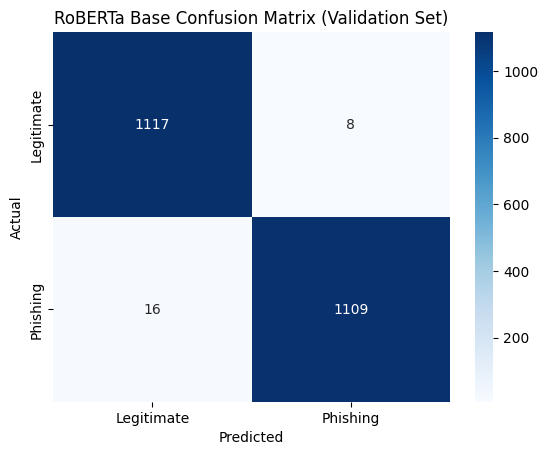

              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      1125
    Phishing       0.99      0.99      0.99      1125

    accuracy                           0.99      2250
   macro avg       0.99      0.99      0.99      2250
weighted avg       0.99      0.99      0.99      2250

False Negatives (missed phishing): 16
False Positives (wrongly flagged): 8

--- Sample False Negatives ---
Subject: instinct greatly
Body snippet: 
THOMPSON PASS 650 AM ADT SUN APR 15 2007 . This same information is available in other file formats including the XML based RSS and CAP formats.
THIS ADVISORY INCLUDES THE COMMUNITIES OF YES BAY AND BELL ISLAND.
SOUTHEAST WIND 20 TO 30 MPH WITH GUSTS UP TO 50 MPH BY MID MORNING.
CLOUDY SKIES WITH R
---
Subject: 911 Anniv Bush Memorial Bill for You
Body snippet: ----------------------------------------------------------
>>  GiftCD Offer Newsletter Confirmation August 8th, 2002
--------------------------------------------

In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Run prediction on validation set
raw_pred_val = trainer.predict(tok_val)
val_y_pred = np.argmax(raw_pred_val.predictions, axis=-1)
val_true = val_df['label'].values

# Confusion matrix
cm = confusion_matrix(val_true, val_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('RoBERTa Base Confusion Matrix (Validation Set)')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(val_true, val_y_pred, target_names=['Legitimate', 'Phishing']))

# Attach predictions to val_df for inspection
val_df['predicted'] = val_y_pred
probs = torch.softmax(torch.tensor(raw_pred_val.predictions), dim=-1).numpy()
val_df['phishing_prob'] = probs[:, 1]

# False Negatives and False Positives
false_negatives = val_df[(val_df['label'] == 1) & (val_df['predicted'] == 0)]
false_positives = val_df[(val_df['label'] == 0) & (val_df['predicted'] == 1)]

print(f"False Negatives (missed phishing): {len(false_negatives)}")
print(f"False Positives (wrongly flagged): {len(false_positives)}")

print("\n--- Sample False Negatives ---")
for _, row in false_negatives.head(3).iterrows():
    print("Subject:", row['subject'])
    print("Body snippet:", str(row['body'])[:300])
    print("---")

print("\n--- Sample False Positives ---")
for _, row in false_positives.head(3).iterrows():
    print("Subject:", row['subject'])
    print("Body snippet:", str(row['body'])[:300])
    print("---")

# Low confidence predictions
val_df['confidence'] = abs(val_df['phishing_prob'] - 0.5)
uncertain = val_df.nsmallest(10, 'confidence')[['subject', 'label', 'predicted', 'phishing_prob']]
print(uncertain)

---
## Code Attribution

List any code snippets, tutorials, or resources you referenced below. Include URLs and a short description of what was adapted.

| Source | URL | What was adapted |
|--------|-----|------------------|
| HuggingFace Trainer tutorial | https://huggingface.co/docs/transformers/training | Fine-tuning loop scaffold |
| *(add more rows as needed)* | | |